# Redukcja szczegółowości mapy stref dostaw dla szybkich pulpitów logistycznych za pomocą PROC GREDUCE

## Podsumowanie dla kierownictwa

Regionalny przewoźnik paczek przechowuje granice swoich obszarów obsługi jako gęste zarysy wielokątów, a pulpity do planowania tras odrysowują je powoli. Ten notatnik syntetyzuje współrzędne granic czterech stref dostaw, wykorzystuje **PROC GREDUCE** do oznaczenia każdego wierzchołka granicy poziomem `DENSITY`, a następnie renderuje kartogram terminowości dostaw za pomocą **PROC GMAP** na zredukowanym poziomie szczegółowości, dzięki czemu mapa rysuje się szybciej, a każda strefa pozostaje rozpoznawalna.

GREDUCE ocenił 96 punktów granicznych, przypisując je do trzech poziomów: 10 punktów na poziomie `DENSITY=0`, 44 na poziomie `DENSITY=2` i 42 na poziomie `DENSITY=3`. Zachowanie tylko zgrubnego poziomu (`DENSITY <= 2`) zmniejsza mapę z 96 do 54 wierzchołków — czyli redukcja o około 44% — a mimo to cztery strefy pozostają wyraźnie rozpoznawalne na poniższym porównaniu obok siebie.

## Źródła danych

Wszystkie dane są generowane wewnętrznie przez poniższe kroki DATA — bez plików zewnętrznych ani dostępu do sieci.

| Zbiór danych | Wiersze | Kluczowe zmienne | Opis |
|---------|------|---------------|-------------|
| `zonemap` | 96 (4 strefy x 24 wierzchołki) | `zone` (ID), `x`, `y` | Syntetyczne współrzędne granic zamkniętego wielokąta dla czterech stref obsługi dostaw, każda w postaci zaburzonej elipsy wyznaczonej przez 24 wierzchołki, tak aby redukcja gęstości miała co przerzedzać. |
| `reducedmap` | 96 | dodaje `density` | Wynik PROC GREDUCE: punkty graniczne oznaczone poziomem `DENSITY` (tutaj 0, 2 lub 3) do selektywnego renderowania. |
| `coarsemap` | 54 | podzbiór `reducedmap` | Podzbiór `DENSITY <= 2` — zgrubny, szybko renderujący się poziom używany dla mapy pulpitu o zredukowanej szczegółowości. |
| `zonekpi` | 4 | `zone`, `ontime_rate`, `parcels` | Jeden wiersz odpowiedzi na strefę: syntetyczny procent terminowości dostaw oraz dzienny wolumen przesyłek, połączony z mapą dla kartogramu. |

> **Uwaga dotycząca wielkości próby.** To środowisko działa bez licencji, więc każdy krok DATA jest ograniczony do 100 obserwacji wyjściowych. Mapa ma rozmiar 4 strefy x 24 wierzchołki = 96 punktów, tak aby całe terytorium mieściło się w tym limicie; licencjonowana instalacja śledziłaby setki wierzchołków na strefę, gdzie GREDUCE przynosi jeszcze większe korzyści.

# Redukcja szczegółowości mapy stref dostaw za pomocą PROC GREDUCE

Operatorzy logistyczni wizualizują wyniki na mapach swoich **obszarów obsługi** — geograficznych stref, za które odpowiada dany depot. Granice tych stref są często rejestrowane w rozdzielczości pomiarowej: wiele wierzchołków na wielokąt. Gdy pulpit do planowania tras odrysowuje kilka stref jednocześnie, cała ta szczegółowość wierzchołków spowalnia renderowanie, nie dodając wartości decyzyjnej przy powiększeniu pulpitu.

**PROC GREDUCE** rozwiązuje ten problem. Analizuje każdy wielokąt i oznacza każdy punkt graniczny poziomem `DENSITY`, gdzie 0 oznacza punkty definiujące zasadniczy kształt, a wyższe poziomy oznaczają coraz drobniejsze szczegóły. Później wybierasz poziom za pomocą `WHERE density <= n`, aby narysować mapę o zredukowanej szczegółowości, która rysuje się szybko, a każda strefa pozostaje rozpoznawalna.

W tym notatniku:
1. Syntetyzujemy zarysy granic czterech stref dostaw.
2. Uruchamiamy PROC GREDUCE, aby przypisać poziomy `DENSITY`.
3. Sprawdzamy, jak punkty rozkładają się na poziomy gęstości.
4. Renderujemy kartogramy terminowości dostaw w pełnej i zredukowanej szczegółowości oraz je porównujemy.

## Krok 1 — Synteza mapy granic stref

Zbiór danych typu mapa SAS ma jedną obserwację na **wierzchołek granicy**, ze zmienną `ID` nazywającą obszar oraz numerycznymi współrzędnymi `x`/`y`. Rysujemy każdą strefę dostaw jako zaburzoną elipsę, wykorzystując 24 równomiernie rozłożone kąty, tak aby wielokąty na starcie były wystarczająco gęste, a redukcja miała na czym pracować.

`call streaminit` ustala strumień losowy dla powtarzalności, a `rand('uniform')` dodaje niewielkie nieregularności do granicy, dzięki czemu zarysy wyglądają jak terytoria z pomiaru geodezyjnego, a nie jak idealne elipsy.

In [1]:
DANE zonemap;
    CALL streaminit(20260531);
    /* Cztery strefy dostaw, każda w postaci wielokąta zbliżonego do elipsy
       o 24 wierzchołkach. cx/cy = środek strefy, rx/ry = promienie nominalne (rozmiar terytorium). */
    TABLICA cx[4] _temporary_ (12 32 20 40);
    TABLICA cy[4] _temporary_ (30 32 14 16);
    TABLICA rx[4] _temporary_ ( 8  9  6  7);
    TABLICA ry[4] _temporary_ ( 6  7  5  6);
    pi = constant('pi');
    nvtx = 23;                 /* 24 wierzchołki (0..23) na obrys */
    POWTÓRZ zone = 1 TO 4;
        POWTÓRZ i = 0 TO nvtx;
            ang = 2 * pi * i / (nvtx + 1);
            /* losowe zaburzenie promienia: +/- ~6%, nieregularna krawędź w stylu linii brzegowej */
            jit = 1 + 0.12 * (rand('uniform') - 0.5);
            x = cx[zone] + rx[zone] * cos(ang) * jit;
            y = cy[zone] + ry[zone] * sin(ang) * jit;
            WYJŚCIE;
        KONIEC;
    KONIEC;
    ZACHOWAJ zone x y;
    ETYKIETA zone="Strefa" x="Współrzędna X" y="Współrzędna Y";
WYKONAJ;

PROCEDURA ŚREDNIE DANE=zonemap n MIN MAX nmiss;
    KLASA zone;
    ZMIENNA x y;
    ETYKIETA zone="Strefa" x="Współrzędna X" y="Współrzędna Y";
WYKONAJ;


                                                  The MEANS Procedure

                                         Analysis Variable : x Współrzędna X

        Strefa            N Obs        Minimum        Maximum         N Miss
        --------------------------------------------------------------------
        1                    24      3.6053386     20.3284433              0
        2                    24     23.0107098     41.2087956              0
        3                    24     13.7607192     26.2351392              0
        4                    24     33.0535851     47.3028874              0
        --------------------------------------------------------------------

                                         Analysis Variable : y Współrzędna Y

        Strefa            N Obs        Minimum        Maximum         N Miss
        --------------------------------------------------------------------
        1                    24     23.9838655     35.9959368              0
  


NOTE: DATA zonemap


NOTE: Wrote zonemap (96 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


Tabela PROC MEANS potwierdza syntetyczną geometrię: cztery strefy, każda z dokładnie 24 punktami granicznymi w rozsądnych zakresach `x`/`y` i bez brakujących współrzędnych. Cztery elipsy zajmują nienakładające się obszary (strefa 1 w okolicy x=12, strefa 2 w okolicy x=32, strefy 3 i 4 niżej), więc kartogram będzie czytelny jako cztery odrębne terytoria. To właśnie te zarysy przerzedzi PROC GREDUCE.

## Krok 2 — Przypisanie poziomów DENSITY za pomocą PROC GREDUCE

Instrukcja `ID` nazywa zmienną definiującą każdy obszar jednostkowy — tutaj `zone`. PROC GREDUCE ocenia wielokąt każdej strefy niezależnie (stosując uproszczenie w stylu Douglasa-Peuckera) i zapisuje zbiór wejściowy z dodaną zmienną całkowitą `density`: poziom 0 oznacza nieliczne punkty kotwiczące zasadniczy kształt, a wyższe poziomy oznaczają coraz drobniejsze szczegóły, które można odrzucić w pierwszej kolejności.

Pozwalamy GREDUCE samodzielnie wyznaczyć progi na podstawie danych, zamiast wymuszać stałe rozmiary poziomów, a następnie sprawdzamy wynikowy rozkład.

                           Liczba zachowanych punktów granicznych na każdym poziomie DENSITY                            

                                                   The FREQ Procedure

Gęstość       Frequency    Percent
-----------------------------------
0                    10     10.42
2                    44     45.83
3                    42     43.75



NOTE: PROC GREDUCE data=zonemap

NOTE: PROC GREDUCE: 96 observations with DENSITY assigned
NOTE: PROC FREQ
NOTE: ODS plot written: freq_density.spec.json
NOTE: PROC FREQ statement used.


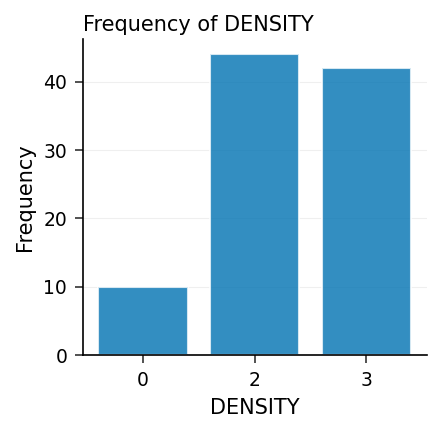

In [2]:
PROCEDURA GREDUCE DANE=zonemap out=reducedmap;
    id zone;
WYKONAJ;

PROCEDURA CZĘSTOŚCI DANE=reducedmap;
    TABLES DENSITY / nocum;
    ETYKIETA DENSITY="Gęstość";
    TYTUŁ 'Liczba zachowanych punktów granicznych na każdym poziomie DENSITY';
WYKONAJ;


## Krok 3 — Analiza poziomów gęstości

Tabela częstości pokazuje, jak GREDUCE ocenił 96 punktów granicznych:

| DENSITY | Punkty | Udział |
|---------|--------|-------|
| 0 | 10 | 10,4% |
| 2 | 44 | 45,8% |
| 3 | 42 | 43,8% |

Tylko 10 punktów niesie najniższy poziom (kotwice zasadniczego kształtu), podczas gdy pozostałe 86 dzieli się między poziomy 2 i 3. Dla poziomu pulpitu zachowujemy wszystko przy `DENSITY <= 2`: co zachowuje 54 z 96 punktów, odrzucając 42 wierzchołki najdrobniejszego szczegółu (`DENSITY=3`). Poniższy PROC MEANS potwierdza, że zgrubny poziom zawiera 13–14 wierzchołków na strefę zamiast pierwotnych 24.

In [3]:
PROCEDURA ŚREDNIE DANE=reducedmap n;
    KLASA zone;
    GDZIE DENSITY <= 2;
    ZMIENNA x;
    ETYKIETA zone="Strefa" x="Współrzędna X";
    TYTUŁ 'Liczba zachowanych wierzchołków na strefę przy szczegółowości pulpitu (DENSITY <= 2)';
WYKONAJ;


                  Liczba zachowanych wierzchołków na strefę przy szczegółowości pulpitu (DENSITY <= 2)                  

                                                  The MEANS Procedure

                                         Analysis Variable : X Współrzędna X

        Strefa            N Obs
        -----------------------
        1                    14
        2                    13
        3                    14
        4                    13
        -----------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Krok 4 — Budowa zgrubnej mapy i odpowiedzi wydajnościowej na strefę

Materializujemy poziom pulpitu jako `coarsemap` (`DENSITY <= 2`), aby PROC GMAP mógł narysować zredukowany zarys bezpośrednio. Syntetyzujemy również jeden wiersz KPI na strefę — **wskaźnik terminowości dostaw** oraz **dzienny wolumen przesyłek** — kluczowany po `zone`, aby GMAP mógł pokolorować każdy obszar.

In [4]:
DANE coarsemap;
    USTAW reducedmap;
    GDZIE DENSITY <= 2;
WYKONAJ;

DANE zonekpi;
    CALL streaminit(771);
    POWTÓRZ zone = 1 TO 4;
        /* wskaźnik terminowości wyśrodkowany w okolicy 92%, realistyczny rozrzut */
        ontime_rate = round(88 + 8 * rand('beta', 5, 2), 0.1);
        parcels     = round(2000 + 6000 * rand('uniform'));
        WYJŚCIE;
    KONIEC;
    ETYKIETA zone="Strefa" ontime_rate="Wskaźnik terminowości (%)" parcels="Liczba przesyłek";
WYKONAJ;

PROCEDURA DRUKUJ DANE=zonekpi noobs ETYKIETA;
    ETYKIETA zone="Strefa" ontime_rate="Wskaźnik terminowości (%)" parcels="Liczba przesyłek";
    TYTUŁ 'Syntetyczne wskaźniki KPI dostaw według strefy';
WYKONAJ;


                                     Syntetyczne wskaźniki KPI dostaw według strefy                                     

Strefa    Wskaźnik terminowości (%)   Liczba przesyłek
     1                         92.6               4704
     2                         95.6               2932
     3                         93.4               2934
     4                         94.6               2516




NOTE: DATA coarsemap


NOTE: Read 96 rows from reducedmap.
NOTE: Wrote coarsemap (54 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA zonekpi


NOTE: Wrote zonekpi (4 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=zonekpi

NOTE: PROC PRINT completed: 4 observations printed, 3 variables


Cztery syntetyczne wskaźniki terminowości mieszczą się między 92,6% a 95,6%, a dzienne wolumeny przesyłek wynoszą od około 2500 do 4700. Strefa 2 jest najlepsza z wynikiem 95,6%; strefa 1 jest najsłabsza z wynikiem 92,6%. To właśnie te wartości kodują pasma kolorów kartogramu.

## Krok 5 — Renderowanie kartogramów w pełnej i zredukowanej szczegółowości

Rysujemy ten sam kartogram terminowości dostaw dwukrotnie: raz z pełnego 96-wierzchołkowego zbioru `reducedmap`, a raz z 54-wierzchołkowego `coarsemap`. `MAP=` dostarcza granice, `DATA=` odpowiedź KPI, a oba dzielą to samo ID `zone`. Instrukcja `CHORO` wypełnia każdą strefę wartością `ontime_rate` z `LEVELS=4` pasmami kolorów oraz `COUTLINE=` dla wyraźnych granic. Porównanie obu map pokazuje, ile kosztuje redukcja wizualnie.

                                      Pełny szczegół: 96 wierzchołków granicznych                                       




NOTE: Option TITLE changed to Pełny szczegół: 96 wierzchołków granicznych.
NOTE: PROC GMAP map=reducedmap data=zonekpi

NOTE: ODS plot written: gmap.spec.json
NOTE: PROC GMAP produced a choropleth map of variable Wskaźnik terminowości (%).
NOTE: 4 map areas were shaded.

NOTE: PROC GMAP elapsed:
  wall  0.43 seconds
  cpu   0.43 seconds


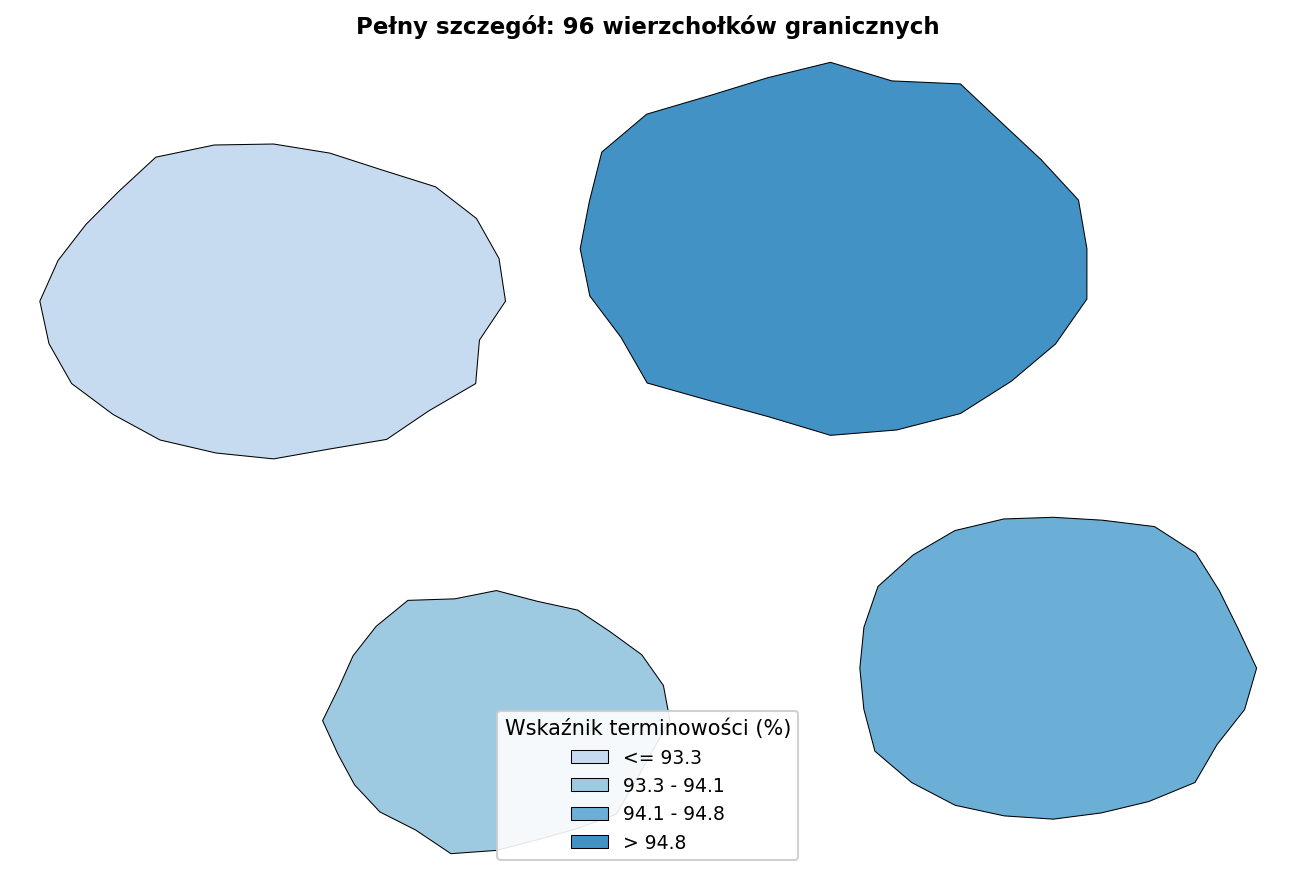

In [5]:
TYTUŁ 'Pełny szczegół: 96 wierzchołków granicznych';
PROCEDURA GMAP map=reducedmap DANE=zonekpi;
    id zone;
    ETYKIETA ontime_rate="Wskaźnik terminowości (%)";
    CHORO ontime_rate / levels=4 coutline=black;
WYKONAJ;


                                  Zredukowany szczegół: 54 wierzchołki (DENSITY <= 2)                                   




NOTE: Option TITLE changed to Zredukowany szczegół: 54 wierzchołki (DENSITY <= 2).
NOTE: PROC GMAP map=coarsemap data=zonekpi

NOTE: ODS plot written: gmap.spec.json
NOTE: PROC GMAP produced a choropleth map of variable Wskaźnik terminowości (%).
NOTE: 4 map areas were shaded.

NOTE: PROC GMAP elapsed:
  wall  0.43 seconds
  cpu   0.43 seconds


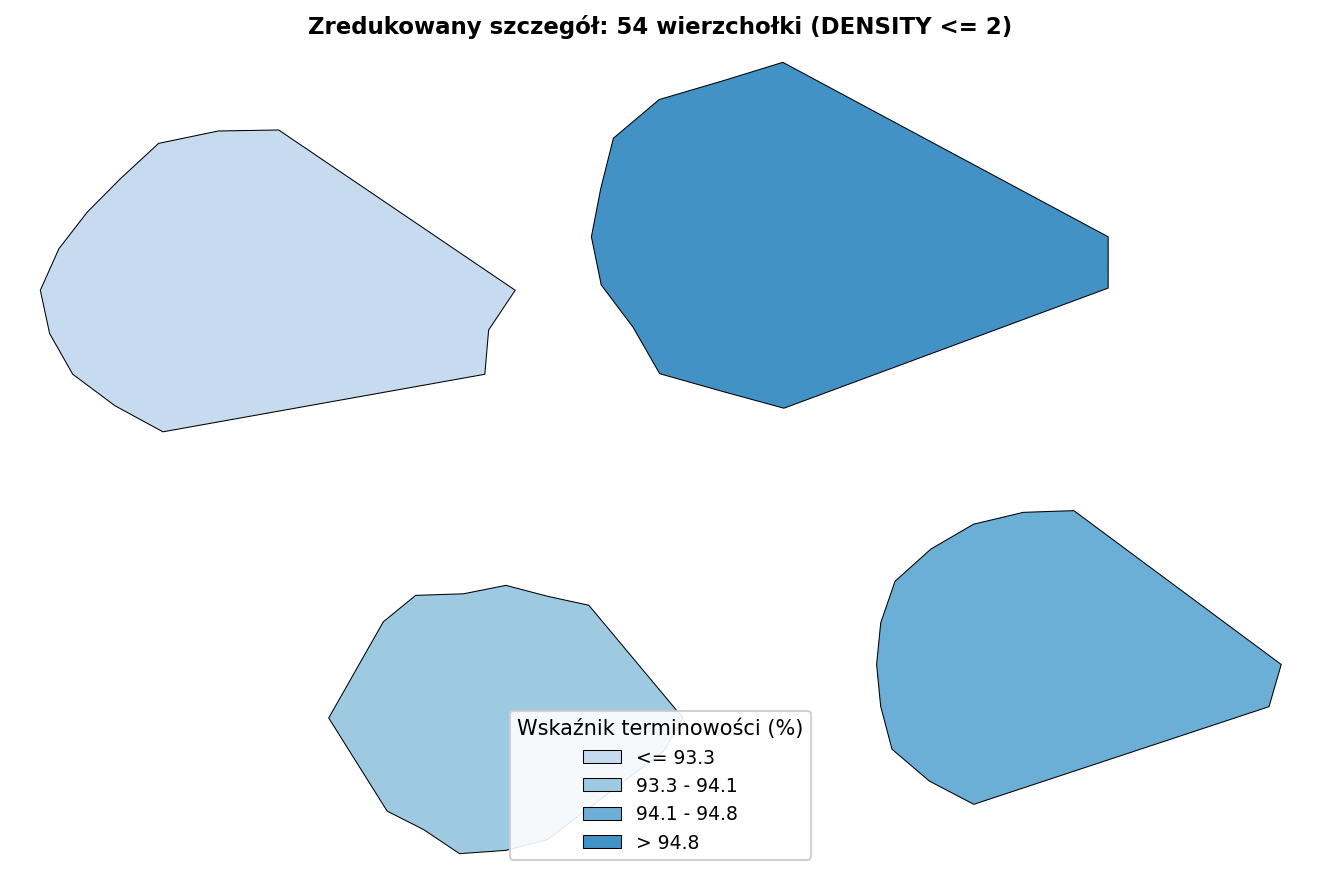

In [6]:
TYTUŁ 'Zredukowany szczegół: 54 wierzchołki (DENSITY <= 2)';
PROCEDURA GMAP map=coarsemap DANE=zonekpi;
    id zone;
    ETYKIETA ontime_rate="Wskaźnik terminowości (%)";
    CHORO ontime_rate / levels=4 coutline=black;
WYKONAJ;


## Interpretacja wyników

PROC GREDUCE przekształcił każdy 24-wierzchołkowy zarys strefy w oceniony zbiór punktów granicznych (poziomy 0, 2 i 3 w tym przebiegu). Wybór poziomu `DENSITY <= 2` zmniejszył mapę z 96 do 54 wierzchołków — redukcja o 44% liczby punktów, które musi narysować renderer — a mimo to zestawione obok siebie kartogramy potwierdzają, że cztery strefy pozostają wyraźnie rozpoznawalne: zarysy zredukowanej mapy są widocznie bardziej kanciaste, ale każde terytorium zachowuje swoje położenie, rozmiar i pasmo kolorystyczne, więc operator odczytuje ten sam wynik niezależnie od wersji.

Ten wynik plasuje strefy według wskaźnika terminowości dostaw: strefa 2 prowadzi z wynikiem 95,6% (najciemniejsze pasmo), strefy 3 i 4 znajdują się w środku stawki w okolicy 93–95%, a strefa 1 zamyka stawkę z wynikiem 92,6% (najjaśniejsze pasmo) — to terytorium, które planista zbadałby najpierw pod kątem problemów z trasowaniem lub przepustowością depotu.

Ponieważ redukcja jest nieniszcząca — punkty pełnej szczegółowości nadal znajdują się w `reducedmap` — ten sam zbiór danych obsługuje zarówno szybki widok pulpitu (`DENSITY <= 2`), jak i widok wysokiej rozdzielczości do druku lub audytu (`DENSITY <= 3` lub pełny zbiór), zmieniając jedynie próg `WHERE`, bez potrzeby ponownego importowania lub redukowania geometrii.